In [3]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd

In [7]:
recaudacion = pd.read_csv(
    "C:/Users/brent/OneDrive/Escritorio/ProyectoImpuestos/Recaudacion/Archivos_exportados/recaudacion_iva_ganancias_total_2020_2025.csv"
)

In [9]:
recaudacion.head()

,anio,impuesto_std,recaudacion_total
0,2020,GANANCIAS,1.302738e+06
1,2020,IVA,1.604043e+06
2,2020,TOTAL,7.607538e+06
3,2021,GANANCIAS,5.808507e+05
4,2021,IVA,9.712435e+05


In [11]:
recaudacion_total = (
    recaudacion
    [recaudacion["impuesto_std"] == "TOTAL"]
    [["anio", "recaudacion_total"]]
    .sort_values("anio")
    .reset_index(drop=True)
)

In [13]:
recaudacion_total

,anio,recaudacion_total
0,2020,7.607538e+06
1,2021,3.955087e+06
2,2023,8.970251e+07
3,2024,3.089811e+08
4,2025,4.214746e+08


PBI

In [15]:
pib_raw = pd.read_excel(
    "C:/Users/brent/OneDrive/Escritorio/ProyectoImpuestos/Presion Tributaria/Archivos/Series trimestrales de oferta y demanda globales. Años 2004-2025.xls"
)

In [17]:
pib_raw.head()
pib_raw.columns

Index(['Índice de cuadros'], dtype='object')

In [19]:
#1️⃣ Ver las hojas del Excel
xls = pd.ExcelFile(
    "C:/Users/brent/OneDrive/Escritorio/ProyectoImpuestos/Presion Tributaria/Archivos/Series trimestrales de oferta y demanda globales. Años 2004-2025.xls"
)

xls.sheet_names

['Índice',
 'cuadro 1',
 'cuadro 2',
 'cuadro 3',
 'cuadro 4',
 'cuadro 5',
 'cuadro 6',
 'cuadro 7',
 'cuadro 8',
 'cuadro 9',
 'cuadro 10',
 'cuadro 11',
 'cuadro 12',
 'cuadro 13',
 'cuadro 14',
 'cuadro 15']

In [21]:
#2️⃣ Leer SOLO el Cuadro 1
pib_raw = pd.read_excel(
    xls,
    sheet_name="cuadro 1"
)

In [23]:
pib_raw.head()
pib_raw.columns

Index(['Cuadro 1', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       ...
       'Unnamed: 120', 'Unnamed: 121', 'Unnamed: 122', 'Unnamed: 123',
       'Unnamed: 124', 'Unnamed: 125', 'Unnamed: 126', 'Unnamed: 127',
       'Unnamed: 128', 'Unnamed: 129'],
      dtype='object', length=130)

In [25]:
pib_raw.columns

Index(['Cuadro 1', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       ...
       'Unnamed: 120', 'Unnamed: 121', 'Unnamed: 122', 'Unnamed: 123',
       'Unnamed: 124', 'Unnamed: 125', 'Unnamed: 126', 'Unnamed: 127',
       'Unnamed: 128', 'Unnamed: 129'],
      dtype='object', length=130)

In [27]:
pib_raw.head(15)

,Cuadro 1,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 120,Unnamed: 121,Unnamed: 122,Unnamed: 123,Unnamed: 124,Unnamed: 125,Unnamed: 126,Unnamed: 127,Unnamed: 128,Unnamed: 129
0,Oferta y demanda globales. Valores trimestrale...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2004,NaN,NaN,NaN,NaN,NaN,2005,NaN,NaN,...,NaN,2024 (2),NaN,NaN,NaN,NaN,NaN,2025 (2),NaN,NaN
3,NaN,1º trimestre,2º trimestre,3º trimestre,4º trimestre,Total,NaN,1º trimestre,2º trimestre,3º trimestre,...,NaN,1º trimestre,2º trimestre,3º trimestre,4º trimestre,Total,NaN,1º trimestre,2º trimestre,3º trimestre
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Producto Interno Bruto,460369.442233,514395.681772,481151.979944,484543.676877,485115.195206,NaN,493602.530578,581668.24988,514697.789505,...,NaN,669057.733385,729947.785275,714524.36555,718991.460937,708130.336286,NaN,708113.80567,776528.776091,737868.049793
6,Importaciones FOB (bienes y servicios reales),73073.434811,80006.307217,85416.072521,88375.321573,81717.784031,NaN,84904.77745,97288.203296,96844.893037,...,NaN,161524.279009,166315.002199,180683.25897,198736.261383,176814.70039,NaN,226188.830887,229490.640598,223524.710759
7,Oferta Global,533442.877044,594401.98899,566568.052465,572918.998449,566832.979237,NaN,578507.308028,678956.453176,611542.682543,...,NaN,830582.012394,896262.787474,895207.62452,917727.722319,884945.036677,NaN,934302.636557,1006019.416689,961392.760552
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Demanda Global,533442.97369,594401.970496,566568.026152,572918.94661,566832.979237,NaN,578507.308028,678956.453176,611542.682543,...,NaN,830582.012394,896262.787474,895207.62452,917727.722319,884945.036677,NaN,934302.636557,1006019.416689,961392.760552


In [29]:
pib_raw = pd.read_excel(
    "C:/Users/brent/OneDrive/Escritorio/ProyectoImpuestos/Presion Tributaria/Archivos/Series trimestrales de oferta y demanda globales. Años 2004-2025.xls",
    sheet_name="cuadro 1",
    header=None,
    dtype=str
)

In [35]:
pib_raw.head()
pib_raw.columns

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       120, 121, 122, 123, 124, 125, 126, 127, 128, 129],
      dtype='int64', length=130)

In [31]:
#Quedarnos con la fila de Producto Interno Bruto
pib_fila = pib_raw.iloc[5, 1:]  # ignoramos la columna 0
pib_fila.head(10)

1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
Name: 5, dtype: object

In [33]:
fila_anios = pib_raw.iloc[2, 1:]
fila_trimestres = pib_raw.iloc[3, 1:]
fila_anios.head(10)

1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
Name: 2, dtype: object

In [35]:
pib_raw.iloc[:10, :15]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,Cuadro 1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Oferta y demanda globales. Valores trimestrale...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,2004,NaN,NaN,NaN,NaN,NaN,2005,NaN,NaN,NaN,NaN,NaN,2006,NaN
4,NaN,1º trimestre,2º trimestre,3º trimestre,4º trimestre,Total,NaN,1º trimestre,2º trimestre,3º trimestre,4º trimestre,Total,NaN,1º trimestre,2º trimestre
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Producto Interno Bruto,460369.4422329487,514395.6817723617,481151.9799435081,484543.6768765623,485115.1952063452,NaN,493602.53057785495,581668.2498796025,514697.78950542817,522255.20005077147,528055.9425034143,NaN,532348.2120169173,614076.3926085439
7,Importaciones FOB (bienes y servicios reales),73073.43481112685,80006.3072174586,85416.07252113911,88375.32157266857,81717.78403059828,NaN,84904.77744994142,97288.20329605682,96844.89303709046,99636.55792383585,94668.60792673114,NaN,96613.8916394867,101743.8617298436
8,Oferta Global,533442.8770440756,594401.9889898202,566568.0524646472,572918.9984492309,566832.9792369434,NaN,578507.3080277963,678956.4531756593,611542.6825425186,621891.7579746073,622724.5504301455,NaN,628962.103656404,715820.2543383874
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
pib = pib_raw.iloc[6:, :]   # desde la fila donde empiezan los datos
pib.head()

,0,1,2,3,4,5,6,7,8,9,...,120,121,122,123,124,125,126,127,128,129
6,Producto Interno Bruto,460369.4422329487,514395.6817723617,481151.9799435081,484543.6768765623,485115.1952063452,NaN,493602.53057785495,581668.2498796025,514697.78950542817,...,NaN,669057.7333851669,729947.7852745531,714524.3655499592,718991.4609365795,708130.3362863973,NaN,708113.8056701763,776528.7760907853,737868.0497927279
7,Importaciones FOB (bienes y servicios reales),73073.43481112685,80006.3072174586,85416.07252113911,88375.32157266857,81717.78403059828,NaN,84904.77744994142,97288.20329605682,96844.89303709046,...,NaN,161524.27900890994,166315.00219915036,180683.25897019324,198736.26138286063,176814.70039027854,NaN,226188.830887252,229490.64059812744,223524.7107592643
8,Oferta Global,533442.8770440756,594401.9889898202,566568.0524646472,572918.9984492309,566832.9792369434,NaN,578507.3080277963,678956.4531756593,611542.6825425186,...,NaN,830582.0123940768,896262.7874737035,895207.6245201525,917727.7223194401,884945.0366766758,NaN,934302.6365574283,1006019.4166889128,961392.7605519922
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,Demanda Global,533442.9736900443,594401.9704962727,566568.0261516126,572918.9466098445,566832.9792369435,NaN,578507.3080277967,678956.4531756593,611542.6825425186,...,NaN,830582.0123940768,896262.7874737035,895207.6245201525,917727.7223194401,884945.0366766758,NaN,934302.6365574283,1006019.4166889128,961392.7605519922


In [39]:
#La columna 0 contiene los nombres (Producto Interno Bruto, etc.).
pib = pib.set_index(0)
pib.head()

,1,2,3,4,5,6,7,8,9,10,...,120,121,122,123,124,125,126,127,128,129
0,,,,,,,,,,,,,,,,,,,,,
Producto Interno Bruto,460369.4422329487,514395.6817723617,481151.9799435081,484543.6768765623,485115.1952063452,NaN,493602.53057785495,581668.2498796025,514697.78950542817,522255.20005077147,...,NaN,669057.7333851669,729947.7852745531,714524.3655499592,718991.4609365795,708130.3362863973,NaN,708113.8056701763,776528.7760907853,737868.0497927279
Importaciones FOB (bienes y servicios reales),73073.43481112685,80006.3072174586,85416.07252113911,88375.32157266857,81717.78403059828,NaN,84904.77744994142,97288.20329605682,96844.89303709046,99636.55792383585,...,NaN,161524.27900890994,166315.00219915036,180683.25897019324,198736.26138286063,176814.70039027854,NaN,226188.830887252,229490.64059812744,223524.7107592643
Oferta Global,533442.8770440756,594401.9889898202,566568.0524646472,572918.9984492309,566832.9792369434,NaN,578507.3080277963,678956.4531756593,611542.6825425186,621891.7579746073,...,NaN,830582.0123940768,896262.7874737035,895207.6245201525,917727.7223194401,884945.0366766758,NaN,934302.6365574283,1006019.4166889128,961392.7605519922
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Demanda Global,533442.9736900443,594401.9704962727,566568.0261516126,572918.9466098445,566832.9792369435,NaN,578507.3080277967,678956.4531756593,611542.6825425186,621891.7579746074,...,NaN,830582.0123940768,896262.7874737035,895207.6245201525,917727.7223194401,884945.0366766758,NaN,934302.6365574283,1006019.4166889128,961392.7605519922


In [41]:
#Seleccionar SOLO el PIB (forma correcta)
pib_fila = pib.loc["Producto Interno Bruto"]
pib_fila

1      460369.4422329487
2      514395.6817723617
3      481151.9799435081
4      484543.6768765623
5      485115.1952063452
             ...        
125    708130.3362863973
126                  NaN
127    708113.8056701763
128    776528.7760907853
129    737868.0497927279
Name: Producto Interno Bruto, Length: 129, dtype: object

In [43]:
#Limpiar columnas inútiles (NaN)
pib_fila = pib_fila.dropna()
pib_fila

1      460369.4422329487
2      514395.6817723617
3      481151.9799435081
4      484543.6768765623
5      485115.1952063452
             ...        
124    718991.4609365795
125    708130.3362863973
127    708113.8056701763
128    776528.7760907853
129    737868.0497927279
Name: Producto Interno Bruto, Length: 108, dtype: object

In [45]:
#Convertir a DataFrame ordenado
pib_df = pib_fila.reset_index()
pib_df.columns = ["periodo", "pib"]
pib_df.head()

,periodo,pib
0,1,460369.4422329487
1,2,514395.6817723617
2,3,481151.9799435081
3,4,484543.6768765623
4,5,485115.1952063452


In [47]:
#Extraer años y trimestres desde el encabezado
# filas de encabezado
fila_anios = pib_raw.iloc[3]
fila_trimestres = pib_raw.iloc[4]

In [49]:
#Ahora armamos los nombres de columnas reales:
columnas = []

anio_actual = None

for a, t in zip(fila_anios, fila_trimestres):
    if not pd.isna(a):
        a_str = str(a)
        if a_str[:4].isdigit():
            anio_actual = int(a_str[:4])
    if not pd.isna(t) and anio_actual is not None:
        columnas.append(f"{anio_actual} - {t}")
    else:
        columnas.append(None)


In [51]:
columnas[:20]

[None,
 '2004 - 1º trimestre',
 '2004 - 2º trimestre',
 '2004 - 3º trimestre',
 '2004 - 4º trimestre',
 '2004 - Total',
 None,
 '2005 - 1º trimestre',
 '2005 - 2º trimestre',
 '2005 - 3º trimestre',
 '2005 - 4º trimestre',
 '2005 - Total',
 None,
 '2006 - 1º trimestre',
 '2006 - 2º trimestre',
 '2006 - 3º trimestre',
 '2006 - 4º trimestre',
 '2006 - Total',
 None,
 '2007 - 1º trimestre']

In [53]:
pib = pib_raw.iloc[6:, :].copy()
pib.columns = columnas

# Setear como índice la PRIMERA columna (conceptos)
pib.index = pib.iloc[:, 0]
pib = pib.iloc[:, 1:]


In [55]:
pib.head()

,2004 - 1º trimestre,2004 - 2º trimestre,2004 - 3º trimestre,2004 - 4º trimestre,2004 - Total,None,2005 - 1º trimestre,2005 - 2º trimestre,2005 - 3º trimestre,2005 - 4º trimestre,...,None,2024 - 1º trimestre,2024 - 2º trimestre,2024 - 3º trimestre,2024 - 4º trimestre,2024 - Total,None,2025 - 1º trimestre,2025 - 2º trimestre,2025 - 3º trimestre
Producto Interno Bruto,460369.4422329487,514395.6817723617,481151.9799435081,484543.6768765623,485115.1952063452,NaN,493602.53057785495,581668.2498796025,514697.78950542817,522255.20005077147,...,NaN,669057.7333851669,729947.7852745531,714524.3655499592,718991.4609365795,708130.3362863973,NaN,708113.8056701763,776528.7760907853,737868.0497927279
Importaciones FOB (bienes y servicios reales),73073.43481112685,80006.3072174586,85416.07252113911,88375.32157266857,81717.78403059828,NaN,84904.77744994142,97288.20329605682,96844.89303709046,99636.55792383585,...,NaN,161524.27900890994,166315.00219915036,180683.25897019324,198736.26138286063,176814.70039027854,NaN,226188.830887252,229490.64059812744,223524.7107592643
Oferta Global,533442.8770440756,594401.9889898202,566568.0524646472,572918.9984492309,566832.9792369434,NaN,578507.3080277963,678956.4531756593,611542.6825425186,621891.7579746073,...,NaN,830582.0123940768,896262.7874737035,895207.6245201525,917727.7223194401,884945.0366766758,NaN,934302.6365574283,1006019.4166889128,961392.7605519922
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Demanda Global,533442.9736900443,594401.9704962727,566568.0261516126,572918.9466098445,566832.9792369435,NaN,578507.3080277967,678956.4531756593,611542.6825425186,621891.7579746074,...,NaN,830582.0123940768,896262.7874737035,895207.6245201525,917727.7223194401,884945.0366766758,NaN,934302.6365574283,1006019.4166889128,961392.7605519922


In [57]:
#Extraer el PBI
pib_pbi = pib.loc["Producto Interno Bruto"].dropna()

In [71]:
pib_pbi.tail()

2024 - 4º trimestre    718991.4609365795
2024 - Total           708130.3362863973
2025 - 1º trimestre    708113.8056701763
2025 - 2º trimestre    776528.7760907853
2025 - 3º trimestre    737868.0497927279
Name: Producto Interno Bruto, dtype: object

In [67]:
pib_pbi.head()

2004 - 1º trimestre    460369.4422329487
2004 - 2º trimestre    514395.6817723617
2004 - 3º trimestre    481151.9799435081
2004 - 4º trimestre    484543.6768765623
2004 - Total           485115.1952063452
Name: Producto Interno Bruto, dtype: object

In [116]:
# 1️⃣ Tomar los totales anuales
pib_2020_2025 = pib_pbi[pib_pbi.index.str.contains("Total")].copy()

# 2️⃣ extraer el año del texto
pib_2020_2025.index = pib_2020_2025.index.str.extract(r'(\d{4})')[0].astype(int)

# 3️⃣ filtrar 2020-2024
pib_2020_2025 = pib_2020_2025[(pib_2020_2025.index >= 2020) & (pib_2020_2025.index <= 2024)]

# 4️⃣ calcular 2025 desde trimestres
pib_2025 = pib_pbi[pib_pbi.index.str.contains("2025")].astype(float).sum()

# 5️⃣ agregar 2025
pib_2020_2025.loc[2025] = pib_2025

# 6️⃣ convertir a dataframe
pib_2020_2025 = pib_2020_2025.reset_index()
pib_2020_2025.columns = ["anio", "pib"]

In [118]:
pib_2020_2025

,anio,pib
0,2020,624591.2861529794
1,2021,689809.9340338551
2,2022,731341.6337271854
3,2023,717769.4832113908
4,2024,708130.3362863973
5,2025,2222510.631554


In [120]:
pib_2020_2025.index

RangeIndex(start=0, stop=6, step=1)

In [128]:
#Exportar a CSV
pib_2020_2025.to_csv(
    r"C:\Users\brent\OneDrive\Escritorio/ProyectoImpuestos/Presion Tributaria/Archivos_exportados/pib_total_anual_2020_2025.csv",
    index=False,
    encoding="utf-8"
)

1️⃣ Evolución del PIB (línea)

Sirve para mostrar crecimiento o caída económica.

In [131]:
import matplotlib.pyplot as plt

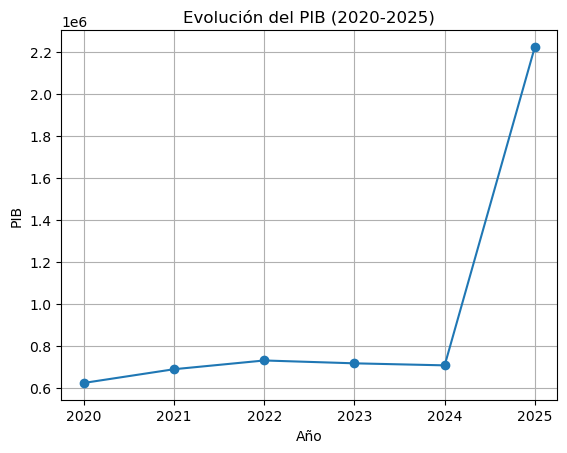

In [139]:
import matplotlib.pyplot as plt
import pandas as pd

pib_2020_2025["anio"] = pd.to_numeric(pib_2020_2025["anio"])
pib_2020_2025["pib"] = pd.to_numeric(pib_2020_2025["pib"])

plt.figure()

plt.plot(pib_2020_2025["anio"], pib_2020_2025["pib"], marker="o")

plt.title("Evolución del PIB (2020-2025)")
plt.xlabel("Año")
plt.ylabel("PIB")

plt.grid(True)

plt.show()

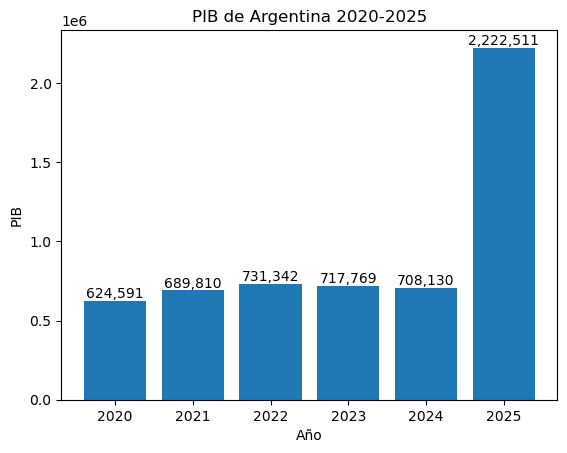

In [145]:
plt.figure()

plt.bar(pib_2020_2025["anio"], pib_2020_2025["pib"])

# etiquetas de los valores
for x, y in zip(pib_2020_2025["anio"], pib_2020_2025["pib"]):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom")

plt.title("PIB de Argentina 2020-2025")
plt.xlabel("Año")
plt.ylabel("PIB")

plt.show()

Variación porcentual del PIB (muy importante)

Este gráfico muestra crecimiento o caída económica entre años.

Primero calculás el crecimiento:

In [148]:
pib_2020_2025["crecimiento_%"] = pib_2020_2025["pib"].pct_change() * 100

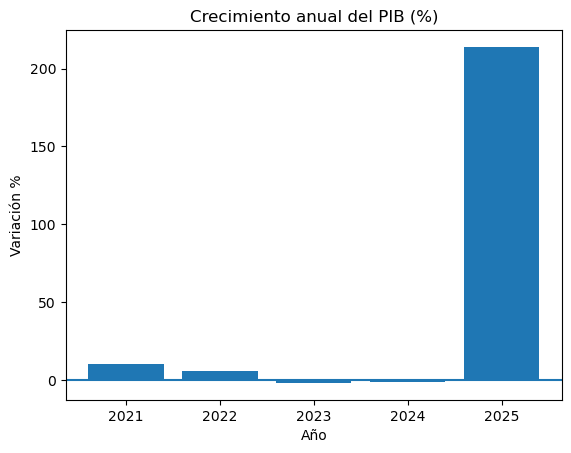

In [150]:
plt.figure()

plt.bar(pib_2020_2025["anio"], pib_2020_2025["crecimiento_%"])

plt.title("Crecimiento anual del PIB (%)")
plt.xlabel("Año")
plt.ylabel("Variación %")

plt.axhline(0)

plt.show()

Qué muestra

recuperación económica

años de caída

impacto de crisis.

PIB acumulado (tendencia económica)

Sirve para ver expansión económica total.

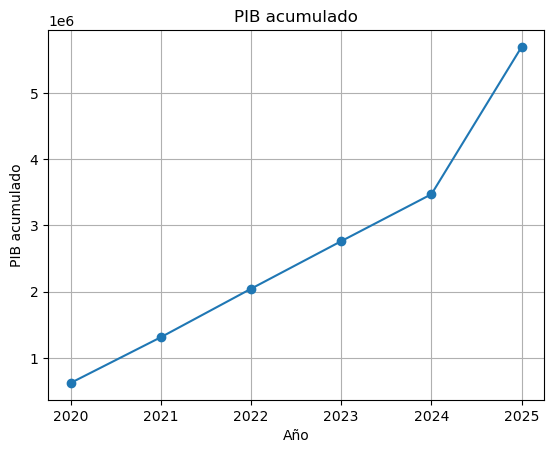

In [154]:
pib_2020_2025["pib_acumulado"] = pib_2020_2025["pib"].cumsum()

plt.figure()

plt.plot(pib_2020_2025["anio"], pib_2020_2025["pib_acumulado"], marker="o")

plt.title("PIB acumulado")
plt.xlabel("Año")
plt.ylabel("PIB acumulado")

plt.grid(True)

plt.show()

Muestra el tamaño creciente de la economía.

Participación de cada año en el total

Este es interesante para análisis macro.